# Region boundaries on the ECCO LLC90 lat-lon-cap grid

This example applies `regionate` to the **ECCOv4r4 native lat-lon-cap (LLC90)** grid — a
genuinely *multi-tile* ocean grid whose 13 tiles are connected by an `xgcm`
`face_connections` topology. It demonstrates regionate's topology-aware boundary
tracing: a region's mask boundary is traced tile-by-tile and **stitched across tile
seams**, so a region that spans several tiles yields a single, continuous boundary
loop with a per-corner face index `f_c`.

The grid is loaded by `load_example_ECCO_grid.load_ECCO_LLC90_grid`, which downloads the
geometry from NASA PO.DAAC (via `earthaccess`; needs a free Earthdata Login) the first
time, renames the MITgcm `XC/YC/XG/YG` coordinates to the `geolon*/geolat*` convention,
and uses `sectionate.gridutils.symmetrize` to convert the native MITgcm 'left'-staggered
grid into the symmetric ('outer') grid that regionate/sectionate operate on.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from load_example_ECCO_grid import load_ECCO_LLC90_grid
from regionate import MaskRegions

grid = load_ECCO_LLC90_grid()
grid

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   i --> outer
  * outer    i_g_outer --> center
Y Axis (not periodic, boundary='fill'):
  * center   j --> outer
  * outer    j_g_outer --> center

## The LLC90 grid

The grid has 13 tiles (`tile` dimension), tracer-center coordinates `geolon`/`geolat`,
and cell-corner coordinates `geolon_c`/`geolat_c` on the symmetric 'outer' position
(one more point than centers along each axis). `Depth` distinguishes ocean from land.
Below, each tile's ocean depth shows the characteristic lat-lon-cap layout (the Arctic
"cap" is tile 6).

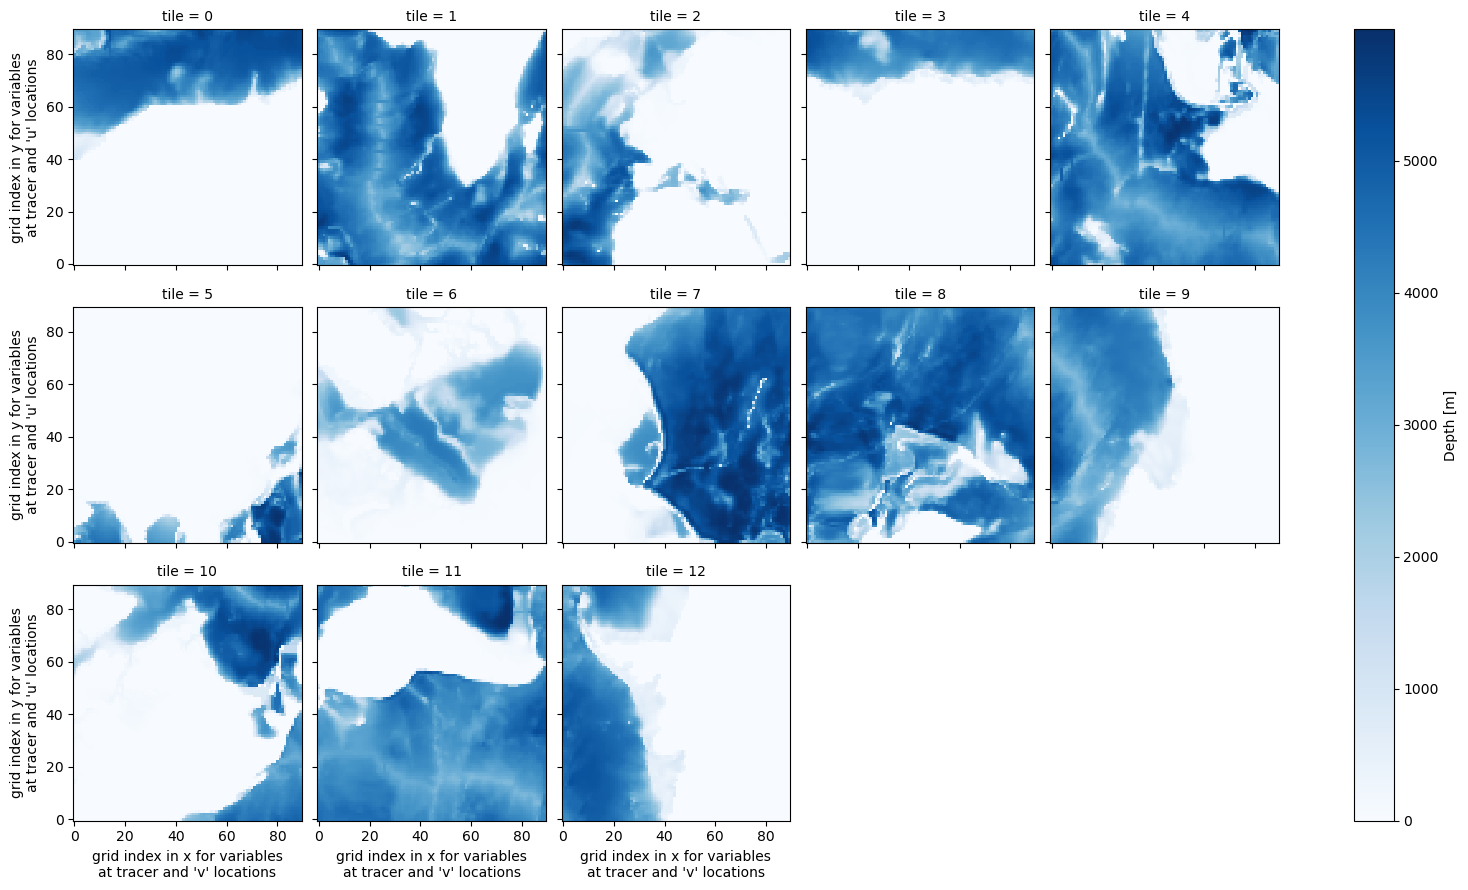

In [2]:
grid._ds["Depth"].plot(col="tile", col_wrap=5, cmap="Blues",
                       cbar_kwargs={"label": "Depth [m]"})
plt.show()

## An Atlantic basin spanning five tiles

We define an Atlantic-basin ocean mask (ocean cells within a lon/lat envelope, extended
north into the Nordic/Arctic seas) and trace its boundary with `MaskRegions`. In the
LLC90 layout the Atlantic occupies the east faces 1 (S) and 2 (N), the west faces 11 (S)
and 10 (N), and reaches onto the Arctic-cap face 6 — so its boundary must be stitched
across several tile seams, including a **rotated** seam (tile 2 ↔ tile 10, an `X`→`Y`
connection) and the **cap** seam (tile 2 ↔ tile 6).

In [3]:
lon = grid._ds["geolon"]
lat = grid._ds["geolat"]
depth = grid._ds["Depth"]

atlantic = (
    (depth > 0) & (
        ((lon > -80) & (lon < 20) & (lat > -35) & (lat < 67)) |   # main basin
        ((lon > -60) & (lon < 20) & (lat >= 67) & (lat < 82))     # Nordic / Arctic sector
    )
).compute()

tiles_in_mask = sorted(set(np.where(atlantic.values.any(axis=(1, 2)))[0].tolist()))
print(f"Atlantic ocean cells: {int(atlantic.sum())}  spanning tiles: {tiles_in_mask}")

regions = MaskRegions(atlantic, grid).region_dict
print(f"number of boundary loops (basin + islands): {len(regions)}")

# The basin perimeter is the largest loop; the rest are islands / interior coastline.
basin = max(regions.values(), key=lambda r: len(r.lons_c))
fc_closed = np.asarray(basin.f_c)
faces = fc_closed[:-1]   # f_c is a closed loop; align with the open lon/lat corners
print(f"basin perimeter: {len(basin.lons_c)} corners, faces = {sorted(set(faces.tolist()))}")
print(f"seam crossings along the perimeter (face changes): "
      f"{int((fc_closed[:-1] != fc_closed[1:]).sum())}")

Atlantic ocean cells: 9941  spanning tiles: [1, 2, 6, 10, 11]
number of boundary loops (basin + islands): 22
basin perimeter: 1109 corners, faces = [1, 2, 6, 10, 11]
seam crossings along the perimeter (face changes): 12


The basin perimeter is a **single closed loop spanning all five tiles**
`[1, 2, 6, 10, 11]`: regionate dropped the internal tile-seam faces and stitched the
surviving boundary across every seam — including the rotated tile-2/tile-10 seam and the
Arctic-cap seam — joining the arcs by grid-corner adjacency from the `face_connections`
topology (the offset corners across rotated seams do not coincide in lon/lat). The
smaller loops are islands and interior coastline.

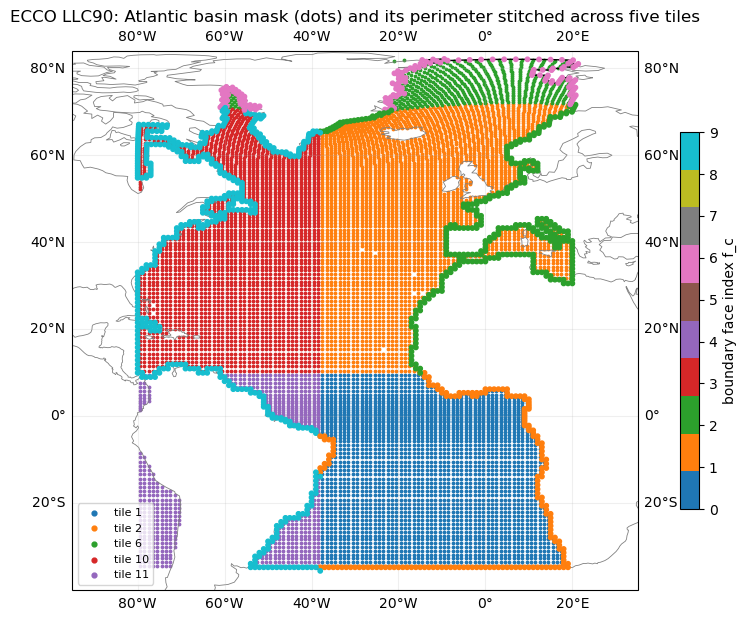

In [4]:
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-95, 35, -40, 84], crs=ccrs.PlateCarree())
ax.coastlines(color="0.5", linewidth=0.6)
ax.gridlines(draw_labels=True, alpha=0.2)

# Atlantic mask cell centers, coloured by tile.
for t in tiles_in_mask:
    m = atlantic.isel(tile=t).values
    ax.scatter(lon.isel(tile=t).values[m], lat.isel(tile=t).values[m],
               s=3, label=f"tile {t}")

# Basin perimeter, with corners coloured by face index f_c.
ax.plot(basin.lons_c, basin.lats_c, "-", color="k", lw=1.0, zorder=4)
sc = ax.scatter(basin.lons_c, basin.lats_c, c=faces, cmap="tab10", vmin=0, vmax=9,
                s=10, zorder=5)
plt.colorbar(sc, ax=ax, label="boundary face index f_c", shrink=0.7)
ax.legend(loc="lower left", fontsize=8, markerscale=2)
ax.set_title("ECCO LLC90: Atlantic basin mask (dots) and its perimeter stitched "
             "across five tiles")
plt.show()

## Notes

- regionate's multi-tile boundary tracing needs only the grid's corner coordinates and
  its `face_connections` topology (via `xgcm` mask padding), so it works directly on the
  symmetrized ECCO grid.
- Stitching across **rotated/reversed** seams (and the Arctic cap) uses the corner
  neighbour maps (`sectionate.gridutils.build_neighbor_maps`) rather than lon/lat
  coincidence, because the two tiles' symmetric corners are offset by a cell across such
  seams. The cap connections rely on correct `xgcm` `face_connections` halo filling
  (xgcm #713).